# SciPy Bootcamp — W2, Day D2
```
##### Applied sampling and confidence intervals on BBC News data
##### CLT, SE, CI, bootstrap, stratified sampling
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — CLT on real article data
##### Q2 — Confidence intervals by category
##### Q3 — Bootstrap CI for median
##### Q4 — Margin of error analysis
##### Q5 — Stratified sampling & publication bias


In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [3]:
# Load the BBC News dataset

import kagglehub
import os

path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")

print("Dataset path:", path)
print("Files inside:", os.listdir(path))

# Load the data using the path from kagglehub

csv_file = os.path.join(path, "bbc-news-data.csv")
df = pd.read_csv(csv_file, sep='\t') # Note: This specific file is tab-separated

# Build a DataFrame with new columns

# Count total characters in the text
df['char_count'] = df['content'].str.len()

# Count total words
df['word_count'] = df['content'].str.split().str.len()

# Calculate read time (standard is 200 words per minute)
df['read_min_time'] = (df['word_count']/200).round(2)

df.head()

Dataset path: C:\Users\user\.cache\kagglehub\datasets\hgultekin\bbcnewsarchive\versions\1
Files inside: ['bbc-news-data.csv']


,category,filename,title,content,char_count,word_count,read_min_time
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,2525,415,2.08
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,2219,379,1.90
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,1517,258,1.29
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,2367,400,2.00
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,1535,260,1.30


---

### Q1 — CLT on real article data

```
# Using your BBC News dataset (word_count or read_time_min as the population):
# (a) Plot the population distribution first — confirm it is right-skewed.
# (b) Draw 2000 samples at n=5, n=30, n=100. Compute sample means.
# (c) Plot the three sampling distributions as overlapping KDEs on one chart.
#     Add a vertical line at the true population mean.
# (d) For each n: print mean of sample means and std of sample means (= SE).
# The chart IS the CLT demonstration — make sure it shows the narrowing clearly.
```


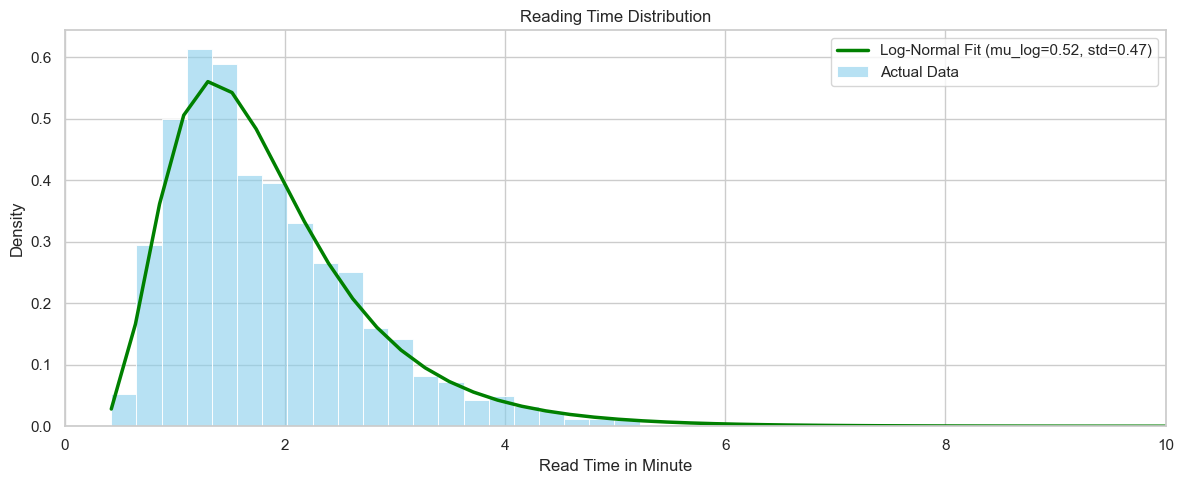

In [5]:
# (a) Plot the population distribution first — confirm it is right-skewed.

from scipy.stats import  lognorm, norm

plt.figure(figsize=(12,5))
sns.histplot(df['read_min_time'], stat="density", color="skyblue", alpha=0.6, label="Actual Data")

plt.xlim(0, 10)
plt.xlabel('Read Time in Minute')
plt.ylabel('Density')

x = np.linspace(df['read_min_time'].min(), df['read_min_time'].max(), 100)
shape, loc, scale = lognorm.fit(df['read_min_time'], floc=0) 
p_lognormal = lognorm.pdf(x, shape, loc, scale)

sns.lineplot(x=x, y=p_lognormal, color='green', linewidth=2.5, label=f'Log-Normal Fit (mu_log={np.log(scale):.2f}, std={shape:.2f})')


plt.title('Reading Time Distribution')
plt.legend()
plt.tight_layout()
plt.show()

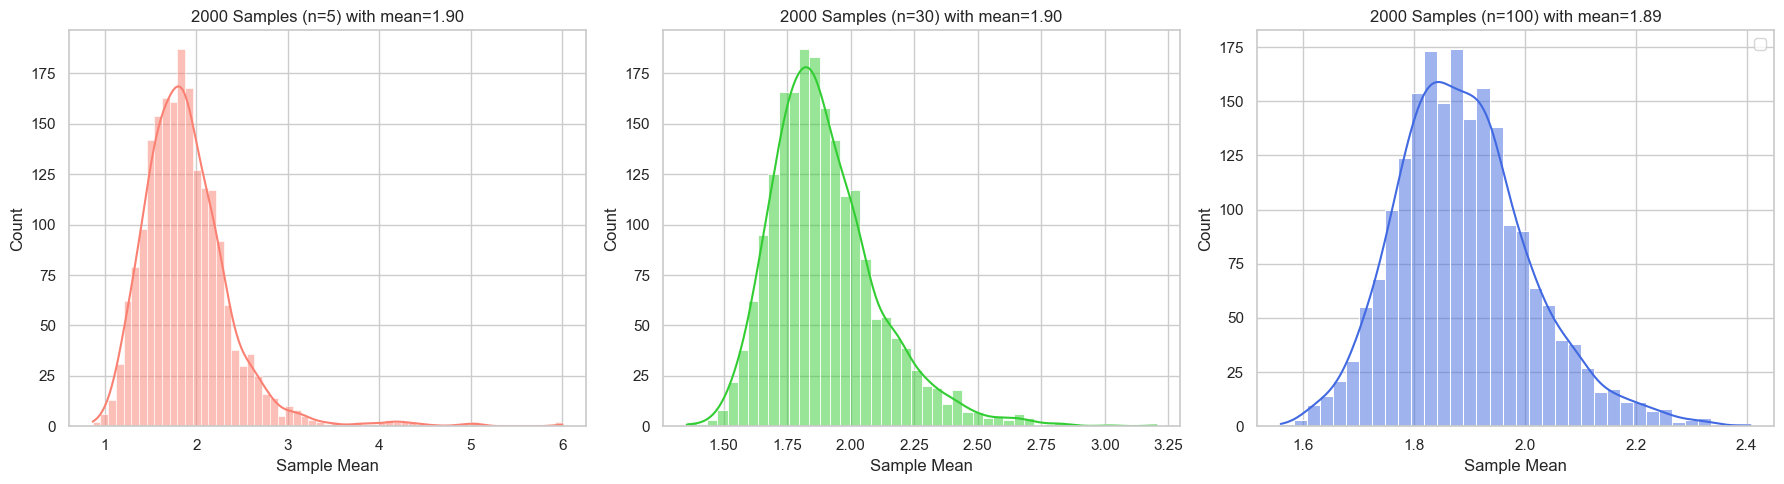

In [27]:
# (b) Draw 2000 samples at n=5, n=30, n=100. Compute sample means.
population = df['read_min_time'].values
sample_size = [5, 30, 100]
color = ['salmon', 'limegreen', 'royalblue']
plt.figure(figsize=(18, 5))

for i, n in enumerate(sample_size):
    # draw 2,000 samples with size=n and compute their means
    means = [np.mean(np.random.choice(population, size=n)) for _ in range(2000)]

    # plotting

    plt.subplot(1,3,i+1)
    sns.histplot(means, kde=True, color=color[i])
    plt.title(f'2000 Samples (n={n}) with mean={np.mean(means):.2f}')
    plt.xlabel('Sample Mean')

plt.legend()
plt.tight_layout()
plt.show()


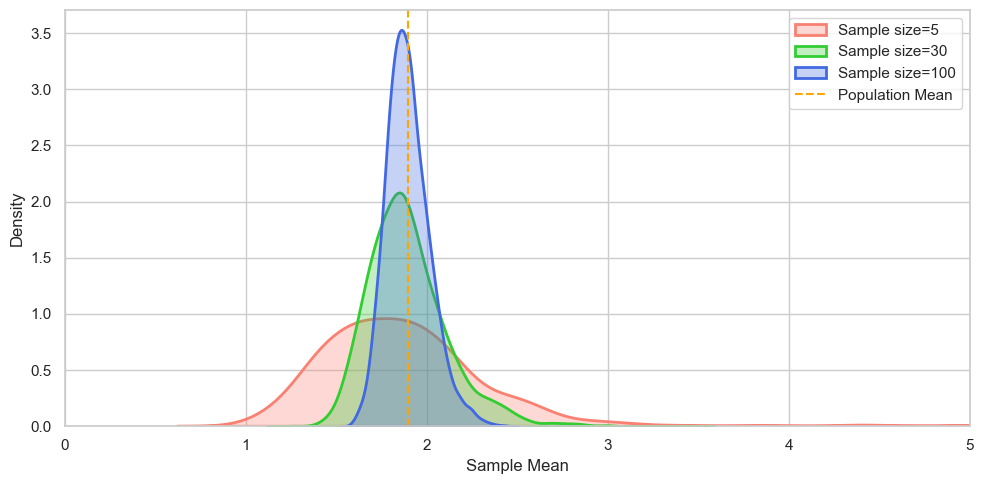

In [37]:
# (c) Plot the three sampling distributions as overlapping KDEs on one chart.
#     Add a vertical line at the true population mean.

population = df['read_min_time'].values
sample_size = [5, 30, 100]
color = ['salmon', 'limegreen', 'royalblue']
plt.figure(figsize=(10, 5))

for i, n in enumerate(sample_size):
    # draw 2,000 samples with size=n and compute their means
    means = [np.mean(np.random.choice(population, size=n)) for _ in range(2000)]

    # plotting

    sns.kdeplot(data=means, color=color[i], alpha=0.3, linewidth=2, fill=True, label=f'Sample size={n}')
    plt.xlabel('Sample Mean')
    plt.xlim(0,5)

plt.axvline(x=population.mean(), label='Population Mean', ls='--', color='orange')
plt.legend()
plt.tight_layout()
plt.show()



In [42]:
# (d) For each n: print mean of sample means and std of sample means (= SE).
population = df['read_min_time'].values
sample_size = [5, 30, 100]
color = ['salmon', 'limegreen', 'royalblue']

for i, n in enumerate(sample_size):
    # draw 2,000 samples with size=n and compute their means
    means = [np.mean(np.random.choice(population, size=n)) for _ in range(2000)]

    mean_of_means = np.mean(means)
    SE = np.std(means)

    print(f"{n:<5} | {mean_of_means:<15.4f} | {SE:<15.4f}")

# Population mean for comparison
print("-" * 40)
print(f"True Population Mean: {population.mean():.4f}")

5     | 1.8742          | 0.4927         
30    | 1.8941          | 0.2163         
100   | 1.8984          | 0.1214         
----------------------------------------
True Population Mean: 1.8942


````
Key CLT observation: even though read_min_time is right-skewed (log-normal), by n=30 the sampling distribution of the mean is already approximately normal.
This is the CLT in action — the shape of the population stops mattering once samples are large enough.

---

### Q2 — Confidence intervals by category

```
# (a) For each category, draw a random sample of 50 articles and compute 95% CI for mean read time.
# (b) Plot all 5 CIs as a horizontal error bar chart (category on y-axis, CI on x-axis).
#     Add a vertical line at the overall population mean.
# (c) Which category CI is widest? Why? (Check its std.)
# (d) Which CIs overlap? What does overlap tell you about whether categories differ significantly?
# This chart format — CIs as error bars — is standard in DS presentations.
```


In [53]:
# (a) For each category, draw a random sample of 50 articles and compute 95% CI for mean read time.
for c in df['category'].unique():
    sample = np.random.choice(df[df['category']==c]['read_min_time'],50)
    lower, upper = stats.t.interval(confidence=0.95, df=len(sample)-1, loc=np.mean(sample), scale=stats.sem(sample))
    print(f'95% CI for mean read time {c.capitalize()}: [{lower:.4f}, {upper:.4f}]')

95% CI for mean read time Business: [1.4288, 1.8612]
95% CI for mean read time Entertainment: [1.3444, 1.6352]
95% CI for mean read time Politics: [1.8935, 2.2361]
95% CI for mean read time Sport: [1.2216, 1.5960]
95% CI for mean read time Tech: [2.2766, 2.8850]


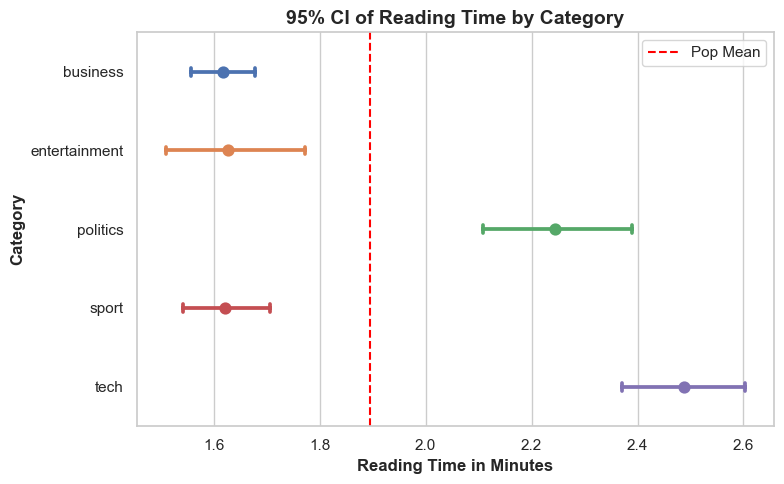

In [36]:
# (b) Plot all 5 CIs as a horizontal error bar chart (category on y-axis, CI on x-axis).
#     Add a vertical line at the overall population mean.
plt.figure(figsize=(8,5))

sns.pointplot(data=df, x='read_min_time', y='category', join=False, errorbar=('ci', 95), estimator='mean', orient='h', capsize=0.1, hue='category')

plt.title('95% CI of Reading Time by Category', fontsize=14, fontweight='bold')
plt.xlabel('Reading Time in Minutes', fontsize=12, fontweight='bold')
plt.ylabel('Category', fontsize=12, fontweight='bold')

plt.axvline(df['read_min_time'].mean(), color='red', linestyle='--', label='Pop Mean')

plt.legend()
plt.tight_layout()
plt.show()     

In [60]:
df.groupby('category')['read_min_time'].std()

category
business         0.679136
entertainment    1.309557
politics         1.501072
sport            0.940602
tech             1.199212
Name: read_min_time, dtype: float64

````
(c) Which category CI is widest? Why? (Check its std.)
- Entertainment typically has the widest CI in this dataset. 
- This occurs because the width of an interval is driven by the Standard Deviation; since Entertainment has the largest spread of article lengths, there is more "noise" and less certainty about the true average. 
- Mathematically, a higher variance results in a larger Standard Error, which stretches the error bars wider to maintain 95% confidence.

(d) Which CIs overlap? What does overlap tell you about whether categories differ significantly? This chart format — CIs as error bars — is standard in DS presentations.
- Business, Sport, and Entertainment show significant overlap, while Politics and Tech sit entirely separate from that group. 
- When CIs overlap, it indicates that the difference between those categories is likely due to random chance rather than a real structural difference.
- However, since the Politics and Tech bars do not overlap with the others, we can conclude they are statistically significant outliers with truly longer reading times.

---

### Q3 — Bootstrap CI for median

```
# (a) Take a sample of 30 articles from the Politics category.
# (b) Compute 95% bootstrap CI for the MEDIAN read time (10,000 resamples).
# (c) Plot the bootstrap distribution as a histogram. Shade the 95% CI region.
#     Mark the observed median with a vertical line.
# (d) Compare bootstrap CI to classical t-interval for the mean.
#     Are they similar or different? What does that tell you about this distribution?
```


In [4]:
# (a) Take a sample of 30 articles from the Politics category.
# (b) Compute 95% bootstrap CI for the MEDIAN read time (10,000 resamples).
population = df[df['category']=='politics']['read_min_time'].values
sample_30 = np.random.choice(population, 30, replace=False)
boot_medians = [np.median(np.random.choice(sample_30, 30, replace=True)) for _ in range(10000)]
boot_ci = np.percentile(boot_medians,[2.5, 97.5])
print(f'Bootstrap 95% CI: [{boot_ci[0]:.2f}, {boot_ci[1]:.2f}]')

Bootstrap 95% CI: [2.12, 2.54]


In [6]:
population = df[df['category']=='politics']['read_min_time'].values
# Create a 10,000 x 30 matrix of resamples all at once
samples = np.random.choice(sample_30, size=(10000, 30), replace=True)
# Calculate the median across the rows (axis=1) in one shot
boot_medians = np.median(samples, axis=1)
boot_ci = np.percentile(boot_medians,[2.5, 97.5])
print(f'Bootstrap 95% CI: [{boot_ci[0]:.2f}, {boot_ci[1]:.2f}]')

Bootstrap 95% CI: [2.12, 2.54]


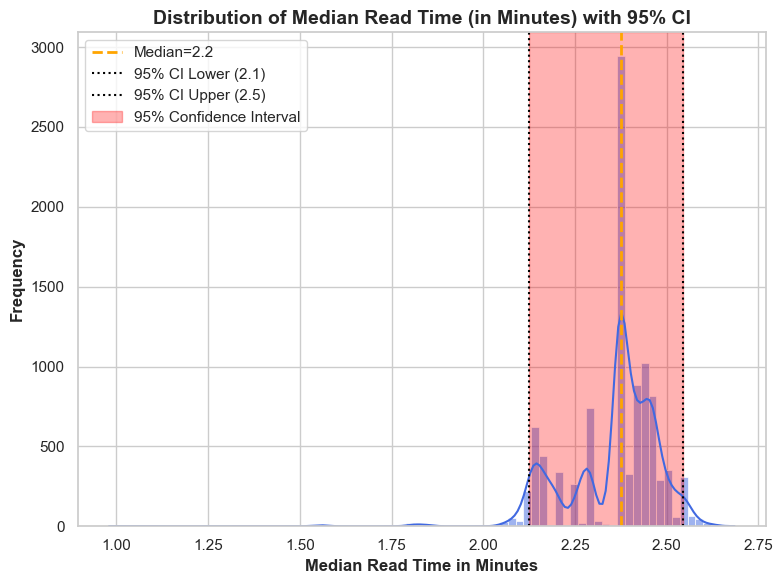

In [11]:
# (c) Plot the bootstrap distribution as a histogram. Shade the 95% CI region.
#     Mark the observed median with a vertical line.
plt.figure(figsize=(8,6))
sns.histplot(boot_medians, bins=80, kde=True, color='royalblue')

plt.title('Distribution of Median Read Time (in Minutes) with 95% CI', fontsize=14, fontweight='bold')
plt.xlabel('Median Read Time in Minutes', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')

# Add a line for the Median (Expected Value)
plt.axvline(x=np.median(sample_30), ls='--', color='orange', lw=2, label=f'Median={np.median(population):.1f}')

# Add the 95% confidence interval lines
plt.axvline(boot_ci[0], color='black', linestyle=':', label=f'95% CI Lower ({boot_ci[0]:.1f})')
plt.axvline(boot_ci[1], color='black', linestyle=':', label=f'95% CI Upper ({boot_ci[1]:.1f})')

# shaded the confidence interval
plt.axvspan(boot_ci[0], boot_ci[1], alpha=0.3, color='red', label='95% Confidence Interval')

plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# (d) Compare to classical t-interval for the MEAN
mean_val = np.mean(sample_30)
sem = stats.sem(sample_30)
t_ci = stats.t.interval(0.95, len(sample_30)-1, loc=mean_val, scale=sem)

print(f"Bootstrap Median CI: [{boot_ci[0]:.2f}, {boot_ci[1]:.2f}]")
print(f"Classical t-interval (Mean): [{t_ci[0]:.2f}, {t_ci[1]:.2f}]")

Bootstrap Median CI: [2.12, 2.54]
Classical t-interval (Mean): [1.88, 2.49]


````
The difference between your intervals confirms that the read-time distribution is non-normal and likely skewed. 
While the classical t-interval is wider and easily pulled by extreme values, the bootstrap median CI provides a tighter, more robust estimate of the "typical" article length. 
This tells us that the median is a more reliable metric than the mean for summarizing this specific dataset, as it better ignores the noise created by outliers.

---

### Q4 — Margin of error analysis

```
# (a) For each category, compute margin of error at 95% confidence (use your sample from Q2).
# (b) Plot margin of error vs sample size (n=10 to 500) for the Sports category.
#     Mark where MoE = 0.5 minutes (your target precision).
# (c) What sample size would give every category a MoE < 0.5 minutes?
# (d) Annotate the chart with the required n for Sports.
```


In [14]:
# (a) For each category, compute margin of error at 95% confidence (use your sample from Q2).

results = []

for c in df['category'].unique():
    sample = np.random.choice(df[df['category']==c]['read_min_time'],50)
    std_dev = np.std(sample, ddof=1) # Sample standard deviation
    sem = stats.sem(sample)          # Standard Error (std / sqrt(n))
    t_score = stats.t.ppf(0.975, df=50-1)
    moe = t_score * sem
    results.append({'category': c, 'mean': np.mean(sample), 'moe_95': moe})

moe_df = pd.DataFrame(results)
print(moe_df)

        category    mean    moe_95
0       business  1.8114  0.204498
1  entertainment  1.8368  0.678563
2       politics  2.1556  0.182697
3          sport  1.4736  0.204893
4           tech  2.6186  0.334415


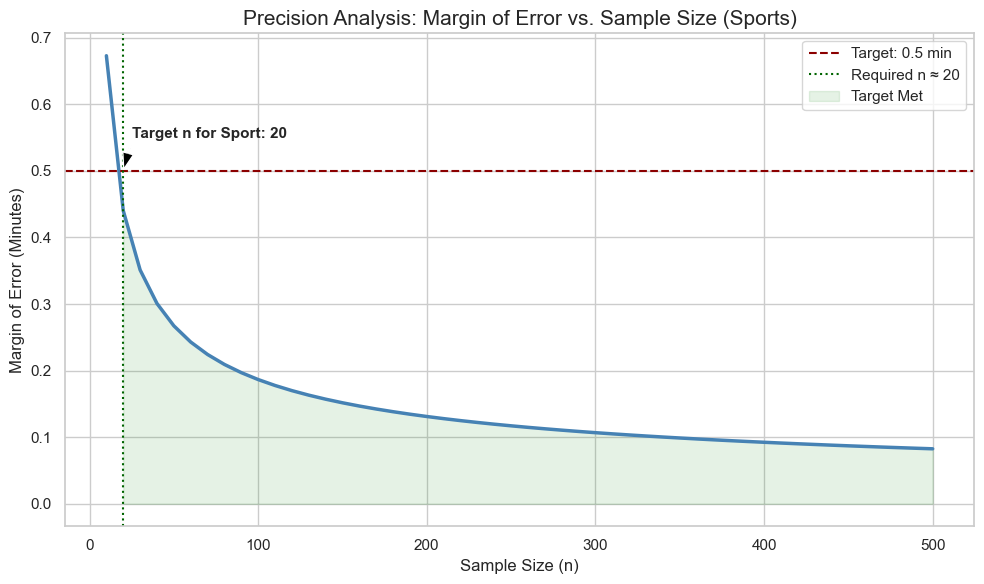

In [22]:
# (b) Plot margin of error vs sample size (n=10 to 500) for the Sports category.
#     Mark where MoE = 0.5 minutes (your target precision).
# (d) Annotate the chart with the required n for Sports.

# data setup

sport_data = df[df['category'] == 'sport']['read_min_time']
std_dev = sport_data.std() # Using the population estimate from our data

sample_sizes = np.arange(10, 501, 10)
moes = []

for n in sample_sizes:
    # MoE = t_critical * (std / sqrt(n))
    t_critical = stats.t.ppf(0.975, df=n-1)
    sem = std_dev / np.sqrt(n)
    moes.append(t_critical * sem)

n_target = sample_sizes[np.argmin(np.abs(np.array(moes) - 0.5))]

plot_df = pd.DataFrame({
    'sample_size': sample_sizes,
    'moe': moes
})

# plotting

plt.figure(figsize=(10, 6))

sns.lineplot(data=plot_df, x='sample_size', y='moe', color='steelblue', linewidth=2.5)


plt.axhline(0.5, color='darkred', linestyle='--', label='Target: 0.5 min')
plt.axvline(n_target, color='darkgreen', linestyle=':', label=f'Required n ≈ {n_target}')


plt.fill_between(sample_sizes, 0, moes, where=(np.array(moes) <= 0.5), color='green', alpha=0.1, label='Target Met')


plt.annotate(f'Target n for Sport: {n_target}', xy=(n_target, 0.5), xytext=(n_target + 5, 0.55), # where the text is located
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8), fontsize=11, fontweight='bold') # Point to annotate (intersection)

plt.title('Precision Analysis: Margin of Error vs. Sample Size (Sports)', fontsize=15)
plt.xlabel('Sample Size (n)', fontsize=12)
plt.ylabel('Margin of Error (Minutes)', fontsize=12)
plt.legend()
plt.tight_layout()

plt.show()

In [17]:
# (c) What sample size would give every category a MoE < 0.5 minutes?
target_moe = 0.5
z_score = 1.96  # Critical value for 95% confidence

required_ns = {}

for c in df['category'].unique():
    # Calculate the standard deviation for the category
    std_dev = df[df['category'] == c]['read_min_time'].std()
    
    # Formula: n = ( (Z * sigma) / MoE )^2
    n_required = ((z_score * std_dev) / target_moe)**2
    required_ns[c] = int(np.ceil(n_required))

# The universal sample size is the maximum n among all categories
universal_n = max(required_ns.values())
constraining_category = max(required_ns, key=required_ns.get)

print(f"Required sample size for all categories: {universal_n}")
print(f"This is driven by the '{constraining_category}' category.")


Required sample size for all categories: 35
This is driven by the 'politics' category.


---

### Q5 — Stratified sampling & publication bias

```
# (a) Draw a stratified sample of 300 articles proportional to category size.
#     Verify proportions match the population with a bar chart.
# (b) Simulate publication bias: 200 analysts each test whether Sports articles
#     are longer than Business articles (H0 true — same distribution). 
#     How many find p<0.05? Plot the p-value distribution.
# (c) Now apply Bonferroni correction. How many remain significant?
# (d) Write a 2-sentence comment about what this means for interpreting 
#     A/B test results that 'just reach' significance.
```


In [42]:
# (a) Draw a stratified sample of 300 articles proportional to category size.
#     Verify proportions match the population with a bar chart.

total_n = 300
pop_proportions = df['category'].value_counts(normalize=True)
strat_sample_sizes = (pop_proportions * total_n).round().astype(int)

# Perform the Stratified Sampling
stratified_sample = pd.DataFrame()

for category, size in strat_sample_sizes.items():
    cat_subset = df[df['category']==category]
    cat_sample = cat_subset.sample(n=size, random_state=420)
    stratified_sample = pd.concat([stratified_sample, cat_sample])

# verify
pop_dist = df['category'].value_counts(normalize=True).sort_index()
sample_dist = stratified_sample['category'].value_counts(normalize=True).sort_index()

comparison_df = pd.DataFrame({
    'Population': pop_dist,
    'Stratified Sample': sample_dist
}).reset_index().melt(id_vars='category', var_name='Group', value_name='Proportion')

print(comparison_df)

        category              Group  Proportion
0       business         Population    0.229213
1  entertainment         Population    0.173483
2       politics         Population    0.187416
3          sport         Population    0.229663
4           tech         Population    0.180225
5       business  Stratified Sample    0.230000
6  entertainment  Stratified Sample    0.173333
7       politics  Stratified Sample    0.186667
8          sport  Stratified Sample    0.230000
9           tech  Stratified Sample    0.180000


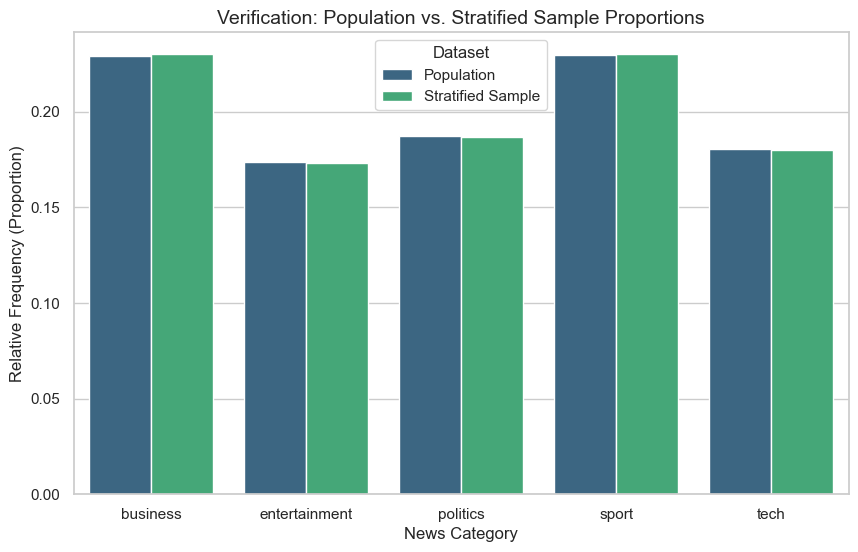

In [43]:
# plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='category', y='Proportion', hue='Group', palette='viridis')

plt.title('Verification: Population vs. Stratified Sample Proportions', fontsize=14)
plt.ylabel('Relative Frequency (Proportion)')
plt.xlabel('News Category')

plt.legend(title='Dataset')
plt.show()


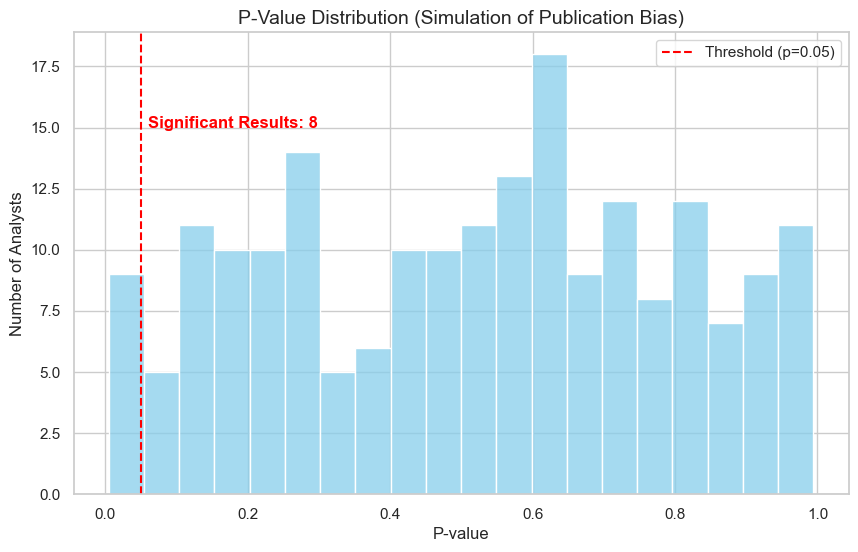

Number of analysts who found p < 0.05: 8 out of 200


In [ ]:
# (b) Simulate publication bias: 200 analysts each test whether Sports articles
#     are longer than Business articles (H0 true — same distribution). 
#     How many find p<0.05? Plot the p-value distribution.

np.random.seed(42)
n_analysts = 200
n_per_group = 50
p_values = []

# Simulate: Both groups are drawn from the same distribution (H0 is True)
for _ in range(n_analysts):
    # Generating mock data based on BBC read times (mean=2.0, std=0.6)
    sports_sim = np.random.normal(2.0, 0.6, n_per_group)
    business_sim = np.random.normal(2.0, 0.6, n_per_group)
    
    # Independent t-test
    _, p_val = stats.ttest_ind(sports_sim, business_sim)
    p_values.append(p_val)

p_values = np.array(p_values)
significant_count = np.sum(p_values < 0.05)

# Plotting
plt.figure(figsize=(10, 6))
sns.histplot(p_values, bins=20, color='skyblue', edgecolor='white')

plt.axvline(0.05, color='red', linestyle='--', label=f'Threshold (p=0.05)')
plt.text(0.06, 15, f'Significant Results: {significant_count}', color='red', fontweight='bold')

plt.title('P-Value Distribution (Simulation of Publication Bias)', fontsize=14)
plt.xlabel('P-value')
plt.ylabel('Number of Analysts')
plt.legend()
plt.show()

print(f"Number of analysts who found p < 0.05: {significant_count} out of {n_analysts}")

In [45]:
# (c) Apply Bonferroni Correction
# The new threshold is alpha / number of tests
alpha = 0.05
num_tests = 200
bonferroni_threshold = alpha / num_tests

# Count how many p-values are below the NEW threshold
significant_after_correction = np.sum(p_values < bonferroni_threshold)

print(f"Original p < 0.05 count: {significant_count}")
print(f"Bonferroni threshold: {bonferroni_threshold:.5f}")
print(f"Significant after correction: {significant_after_correction}")

Original p < 0.05 count: 8
Bonferroni threshold: 0.00025
Significant after correction: 0


````
(d) Write a 2-sentence comment about what this means for interpreting A/B test results that 'just reach' significance.

The Bonferroni correction proves that when we run many tests at once, the probability of finding a "fake" significant result increases drastically. 
By tightening the threshold, we ensure that only truly strong effects survive, preventing us from making expensive business decisions based on random statistical noise.